There is one more task before we can turn the tokens into embeddings: implementing an efficient data loader, that iterates over the input dataset and return the input and target Pytorch tensors, which can be thought of as multidimensional arrays.

We will implement a data loader that fetches input-output target pairs using a sliding approach.

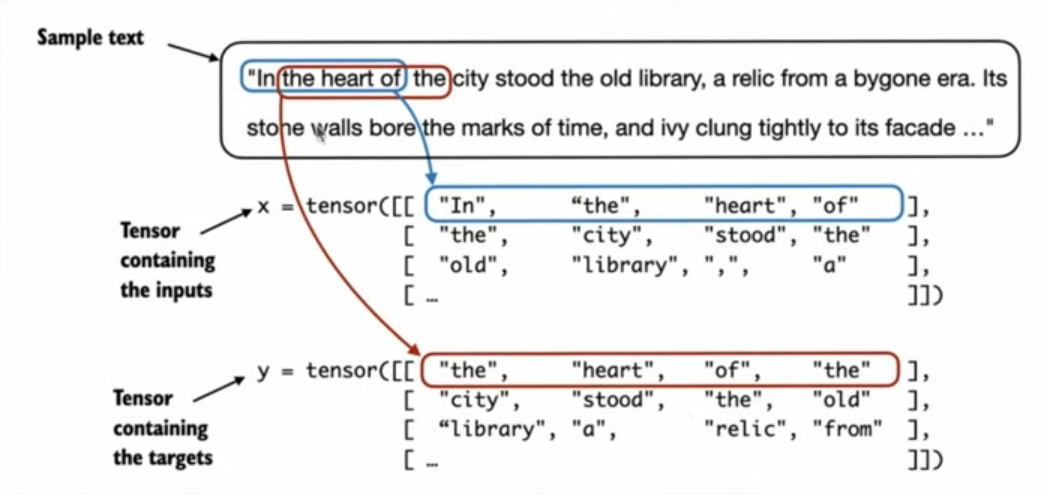

In [18]:
from IPython.display import Image
Image("images/Data_loader.png")

Step1: Tokenize the entire text

Step2: Use sliding windows to chunk the text into overlapping sequence of max_length

Step3: Return the total number of rows in the dataset

Step4: Return a single row from dataset

In [2]:
from torch.utils.data import Dataset, DataLoader

In [3]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max__length, stride):
        self.input_ids = []
        self.target_ids = []

        # tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # use sliding widow to chunk te text dat ainto overlapping sequence of max_length
        for i in range(0, len(token_ids) - max__length, stride):
            input_chunk = token_ids[i:i + max__length]
            target_chunk = token_ids[i + 1:i + max__length + 1]

            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))


    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    

The class above defines how individual rws are fetched from the dataset

Each row consist of the number of token IDs (based on max_length) assigned to an input_chunk tensor

The target_chunk tensor contains the correspondng target

The following code will use the GPTDatasetV1 to load the inputs in a batches via Pytorch Dataloader

Step1: Initialize te tokenizer

Step2: Create Dataset

Step3: drop_last = True ; drops the last batch if it is shorter than the pecified batch_size to prevent loass spikes during training

Step4: The number of CPU processes to use for preprocessing

In [11]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    # initilize tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    #create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # create dataloader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)
    
    return dataloader


In [12]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [13]:
import torch
import tiktoken
print("Pytorch version:", torch.__version__)

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First batch:", first_batch)

Pytorch version: 2.10.0+cu126
First batch: [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


The 1st batch contains two tensors: the 1st tensor stores the input token IDs & the 2nd tensor stores the target token IDs

Since max_length is 4, each of the two tensor contains 4 token IDs

Note: Input size of 4 is very small & it is common to train LLMs with input size of 256

In [14]:
second_batch = next(data_iter)
print("Second batch:", second_batch)

Second batch: [tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


We can see that the second batch token IDs are shifted by 1

The stride setting indicates the number of positions the input shifts across batches, emulating sliding window approach

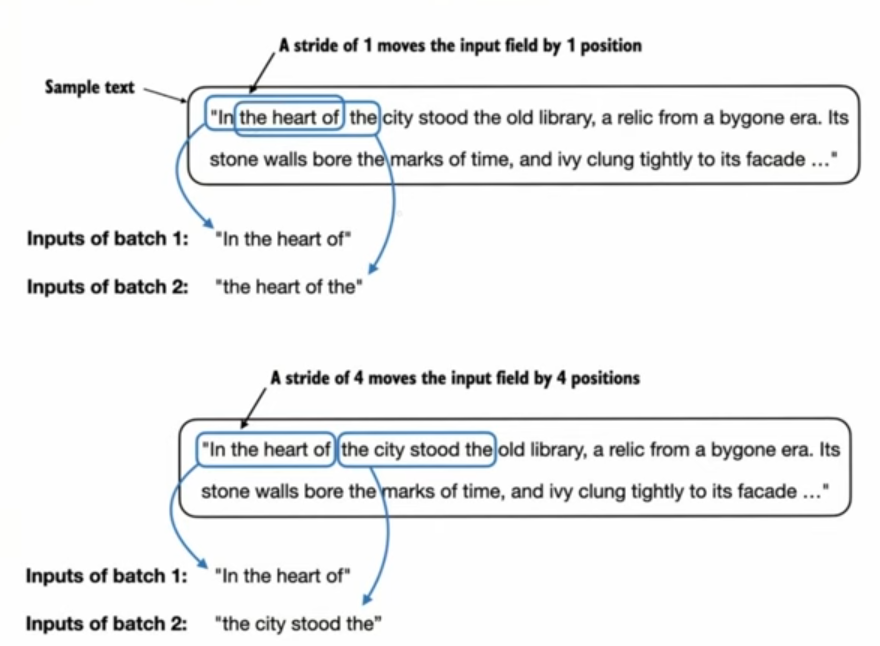

In [19]:
Image("images/stride_length.png")

Just like in Deep Learning, the batch_size is a trade-off and hyperparameter to experiment when training LLMs

Smalss batch_size requires less memory, but lead to more costly model updates

Change batch size

In [16]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, target = next(data_iter)
print("Inputs:", inputs)
print("Target:", target)

Inputs: tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Target: tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


We have increased the stride to 4, this helps to cover dataset fully, but also to avoid overlap between batches

More overlap causes more overfitting.